# YOLO using CVAT

## ❗ Before you start, change runtime type to GPU!!! ❗
**Runtime > Change Runtime Type > GPU (any) > Save**

Change


## I. Labelling dataset preparation

1. **Set up environment**

In [ ]:
!pip install git+https://github.com/WLi0777/LearnTracking.git
!pip install ultralytics
!pip install --upgrade torch torchvision torchaudio
import os

2. **Prepare folders and environment**

**Optional: mount your google drive.**

*You can proceed without doing so, but all progress will be stored in ephemeral memory that will be lost when Colab runtime is disconnected*

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# setup working directory
os.makedirs('/content/drive/MyDrive/YOLO_butterflies', exist_ok=True)
working_path = '/content/drive/MyDrive/YOLO_butterflies'
os.chdir(working_path)

In [ ]:
from dataprep.video_extraction import extract_frames
from dataprep.setup_folders import create_folders_yolo
from google.colab import files
import shutil
import os

if 'working_path' not in locals():
  working_path = '/content/'
  os.chdir(working_path)

video_folder    = os.path.join(working_path,"original_video")
frames_folder   = os.path.join(working_path,"frames_for_labeling")
labeled_folder  = os.path.join(working_path,"yolo_folder")
total_frames    = os.path.join(working_path,"frames_for_labeling/total_video_frames")

create_folders_yolo(video_folder, frames_folder, labeled_folder, total_frames)

3. **❗Upload the videos to /content/original_video**❗

(or if you mounted your Google drive: /content/drive/MyDrive/YOLO/original_video)

**For the purposes of this tutorial we will use this time lapse video of empbryonic cell mitosis from the Cell Image Library.**

*Download the .mp4 via this link: https://www.cellimagelibrary.org/download/web_mp4/15798*

In [ ]:
# Get video files
video_files = sorted([f for f in os.listdir(video_folder) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))])
if video_files:
    print("All Video Files:", video_files)
else:
    print("No video files found.")

In [ ]:
# extract frames
extract_frames(
        input_path = video_folder,
        output_folder = frames_folder,
        frame_number = 40,  # percentage = 100 or frame_number = 10
        method = "kmeans"  # Choose "uniform" or "random" or "kmeans"
        )

shutil.make_archive(frames_folder, 'zip', frames_folder)
files.download(os.path.join(working_path,'frames_for_labeling.zip'))

## II. Labeling - CVAT


1. **Create a New Task**:
   - Task Name: `MitosisDetection`
   - Labels (Constructor): `Add Label`
   - Label Name: `MitosisEvent`
   - Type: `Rectangle`
   - Click `Continue` to save the setting

   **Upload Frames**:
   - Under `Select Files`, upload the frames
   - Click `Submit & Continue` to save
   

2. **Start Labeling**:
   - In the `Jobs` section, find the job to label and start the labeling process
   - Selecet 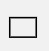, choose `By 2 points` & `Shape`

3. **Save Labeling**:
   - Click `Menu` and select `Export job dataset`
   - Export format: **`Ultralytics YOLO Detection 1.0`**
   - Save, download the file


4. **Upload Labeling**:
   - Upload .zip file to /content/yolo_folder
   (or if you mounted your Google drive: /content/drive/MyDrive/YOLO/yolo_folder)

## III. YOLO Training Dataset Preparation

In [ ]:
from dataprep.yolo_prep import prepare_yolo_dataset, find_yaml_file
total_frames    = os.path.join(working_path,"frames_for_labeling/total_video_frames")
prepare_yolo_dataset(
        base_folder=labeled_folder,
        source_images_folder=total_frames,
        train_percentage=80
    )

yaml_file = find_yaml_file(labeled_folder)

## IV. YOLO Training

In [ ]:
from ultralytics import YOLO
import os
# Load a model
model = YOLO("yolo26s.pt")  # load a pretrained model (recommended for training)
# model = YOLO("/content/drive/MyDrive/YOLO/runs/detect/train6/weights/last.pt")  # load a pretrained model (recommended for training)

if yaml_file:
    # Train the model
    results = model.train(data=yaml_file, epochs=100, imgsz=640)
else:
    print("Can not find the yaml file")

## V. View Model Output

Load the customised model and annotate the original video.

In [ ]:
import re
import glob
# Path to runs/detect/
detect_path           = os.path.join(working_path, 'runs/detect')
# Get all training run folders (train, train1, train2, ...)
train_folders         = [d for d in os.listdir(detect_path) if d.startswith('train') and os.path.isdir(os.path.join(detect_path, d))]
# Extract numbers and sort to find the highest
train_folders_sorted  = sorted(train_folders, key=lambda x: int(re.search(r'\d*$', x).group() or 0), reverse=True)
# Find the latest training run
latest_train_folder   = train_folders_sorted[0]
weights_path          = os.path.join(detect_path, latest_train_folder, 'weights')
# Find best.pt inside the latest training run
best_model_paths      = sorted(glob.glob(os.path.join(weights_path, "best.pt")), key=os.path.getmtime, reverse=True)
latest_model_path     = best_model_paths[0]

# Load the trained YOLO model
print(f"Loading model from: {latest_model_path}")
model   = YOLO(latest_model_path)

# --------------------------------------------------
# For this tutorial, just analyse the first video
# in the folder rather than looping through all videos
# --------------------------------------------------
video = video_files[0]
video_path = os.path.join(video_folder, video)
video_name = os.path.splitext(video)[0]
print(f"Using first video in folder for tutorial: {video}")

# Run YOLO track on the video
results = model.track(
    source=video_path,
    save=True,
    project=os.path.join(video_folder, 'Annotated_video'),
    name=video_name,
    tracker="bytetrack.yaml",
    persist=True,
    conf=0.1,
    iou=0.7
)

You can now find the annotated video in the folder /content/original_video/Annotated_video  (or if you mounted your Google drive: /content/drive/MyDrive/YOLO/original_video/Annotated_video)

## VI. Post-processing - cleaning the trajectories

First, let's plot the trajectories as they are from YOLO/ByteTrack. Bear in mind that we only trained a few frames, so tracking performance is limited. You are welcome to label more frames and see how tracking performance improves

The following section stores our results in a dataframe, then plots the raw trajectories

In [54]:
import pandas as pd

rows = []

for frame_idx, r in enumerate(results):
    if r.boxes is None or len(r.boxes) == 0:
        continue
    if r.boxes.id is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    ids = r.boxes.id.cpu().numpy().astype(int)
    confs = r.boxes.conf.cpu().numpy()

    for box, track_id, conf in zip(boxes, ids, confs):
        x1, y1, x2, y2 = box
        xc = 0.5 * (x1 + x2)
        yc = 0.5 * (y1 + y2)

        rows.append({
            "video": video_name,
            "frame": frame_idx,
            "track_id": track_id,
            "conf": float(conf),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "xc": float(xc),
            "yc": float(yc),
            "w": float(x2 - x1),
            "h": float(y2 - y1),
        })

traj_df = pd.DataFrame(rows)
traj_df.head()

,video,frame,track_id,conf,x1,y1,x2,y2,xc,yc,w,h
0,Butterflies_C0270_Herato,0,1,0.864489,698.928101,186.075256,764.238953,249.622650,731.583496,217.848953,65.310852,63.547394
1,Butterflies_C0270_Herato,1,1,0.834821,698.793579,186.983673,762.395325,248.827103,730.594482,217.905396,63.601746,61.843430
2,Butterflies_C0270_Herato,2,1,0.850363,703.082520,187.032837,764.729248,246.911041,733.905884,216.971939,61.646729,59.878204
3,Butterflies_C0270_Herato,3,1,0.869188,706.782288,186.422729,767.583008,245.430679,737.182617,215.926697,60.800720,59.007950
4,Butterflies_C0270_Herato,3,3,0.344862,814.177856,653.609863,878.489685,709.979492,846.333740,681.794678,64.311829,56.369629


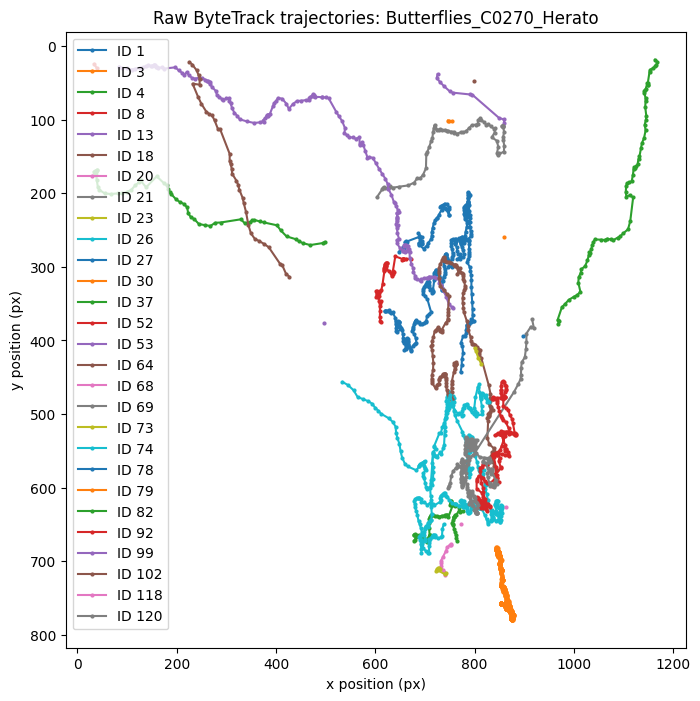

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for track_id, grp in traj_df.groupby("track_id"):
    grp = grp.sort_values("frame")
    plt.plot(grp["xc"], grp["yc"], marker='o', markersize=2, label=f"ID {track_id}")

plt.gca().invert_yaxis()
plt.xlabel("x position (px)")
plt.ylabel("y position (px)")
plt.title(f"Raw ByteTrack trajectories: {video_name}")
plt.legend()
plt.show()

Let's try to clean this by removing duplicated detections and short trajectories, and linking any small gaps

In [56]:
import numpy as np
import pandas as pd

def deduplicate_same_frame(df, dist_thresh=25):
    df = df.copy().sort_values(["frame", "conf"], ascending=[True, False]).reset_index(drop=True)
    keep = []

    for frame, g in df.groupby("frame"):
        accepted = []
        for idx, row in g.iterrows():
            x, y = row["xc"], row["yc"]
            dup = False

            for prev in accepted:
                d = np.hypot(x - prev["xc"], y - prev["yc"])
                if d < dist_thresh:
                    dup = True
                    break

            if not dup:
                accepted.append(row)
                keep.append(idx)

    return df.loc[keep].sort_values(["track_id", "frame"]).reset_index(drop=True)

def stitch_tracks_auto(
    df,
    track_col="track_id",
    frame_col="frame",
    x_col="xc",
    y_col="yc",
    conf_col="conf",
    min_len=5,
    max_gap=15,
    max_dist=40,
    max_speed=8,
):
    df = df.copy().sort_values([track_col, frame_col]).reset_index(drop=True)

    lengths = df.groupby(track_col).size()
    keep_ids = lengths[lengths >= min_len].index
    df = df[df[track_col].isin(keep_ids)].copy()

    summary_rows = []
    for tid, g in df.groupby(track_col):
        g = g.sort_values(frame_col)
        summary_rows.append({
            "track_id": tid,
            "start_frame": g[frame_col].iloc[0],
            "end_frame": g[frame_col].iloc[-1],
            "start_x": g[x_col].iloc[0],
            "start_y": g[y_col].iloc[0],
            "end_x": g[x_col].iloc[-1],
            "end_y": g[y_col].iloc[-1],
            "mean_conf": g[conf_col].mean(),
            "n": len(g),
        })

    S = pd.DataFrame(summary_rows).sort_values("start_frame").reset_index(drop=True)

    parent = {tid: tid for tid in S["track_id"]}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return

        a_start = S.loc[S["track_id"] == ra, "start_frame"].iloc[0]
        b_start = S.loc[S["track_id"] == rb, "start_frame"].iloc[0]

        if a_start <= b_start:
            parent[rb] = ra
        else:
            parent[ra] = rb

    candidates = []
    for _, a in S.iterrows():
        for _, b in S.iterrows():
            if a["track_id"] == b["track_id"]:
                continue

            gap = b["start_frame"] - a["end_frame"]
            if gap <= 0 or gap > max_gap:
                continue

            dist = np.hypot(b["start_x"] - a["end_x"], b["start_y"] - a["end_y"])
            if dist > max_dist:
                continue

            speed = dist / gap
            if max_speed is not None and speed > max_speed:
                continue

            candidates.append({
                "from_id": a["track_id"],
                "to_id": b["track_id"],
                "gap": gap,
                "dist": dist,
                "speed": speed,
                "score": dist + 2 * gap
            })

    cand_df = pd.DataFrame(candidates)

    if len(cand_df) == 0:
        df["track_id_clean"] = df[track_col]
        return df, S, cand_df

    used_from = set()
    used_to = set()
    cand_df = cand_df.sort_values(["score", "dist", "gap"]).reset_index(drop=True)

    for _, row in cand_df.iterrows():
        a = row["from_id"]
        b = row["to_id"]

        if a in used_from or b in used_to:
            continue
        if find(a) == find(b):
            continue

        union(a, b)
        used_from.add(a)
        used_to.add(b)

    df["track_id_clean"] = df[track_col].map(lambda x: find(x))
    return df, S, cand_df

In [57]:
traj_df2 = deduplicate_same_frame(traj_df, dist_thresh=25)

df3, summary, merge_candidates = stitch_tracks_auto(
    traj_df2,
    min_len=5,
    max_gap=15,
    max_dist=40,
    max_speed=8
)

print("raw IDs    :", traj_df["track_id"].nunique())
print("after dedup:", traj_df2["track_id"].nunique())
print("clean IDs  :", df3["track_id_clean"].nunique())

unique_ids            = sorted(df3["track_id_clean"].dropna().astype(int).unique())
id_renumber_map       = {old_id: new_id for new_id, old_id in enumerate(unique_ids, start=1)}
df3["track_id_clean"] = df3["track_id_clean"].map(id_renumber_map)

raw IDs    : 28
after dedup: 28
clean IDs  : 12


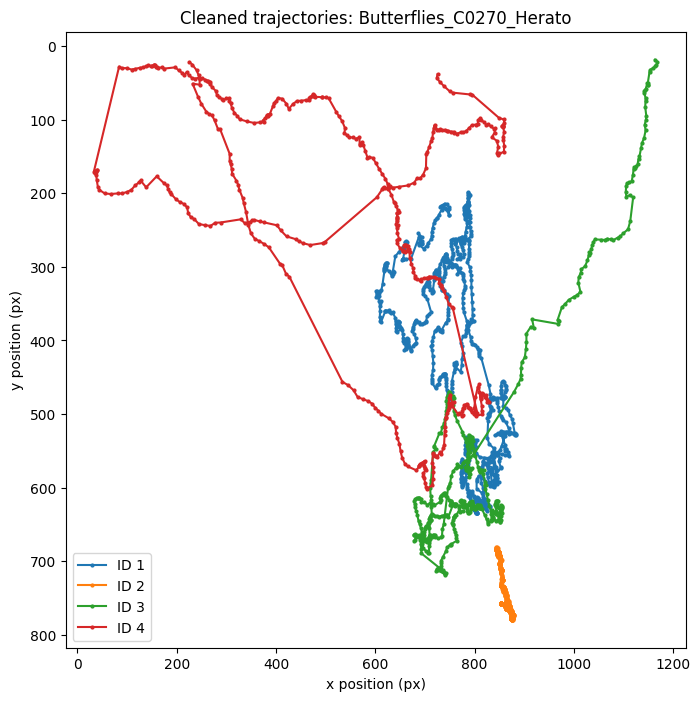

In [81]:
plt.figure(figsize=(8, 8))

for track_id, grp in df3.groupby("track_id_clean"):
    grp = grp.sort_values("frame")
    plt.plot(grp["xc"], grp["yc"], marker='o', markersize=2, label=f"ID {track_id}")

plt.gca().invert_yaxis()
plt.xlabel("x position (px)")
plt.ylabel("y position (px)")
plt.title(f"Cleaned trajectories: {video_name}")
plt.legend()
plt.show()

Now is a manual clean-up. Link any trajectories you think might be from the same butterfly.

In [80]:
# if ID 7 and 12 are the same, merge them
#   12 --> 7
#   12 : 7
merge_map = {
    5: 3,
}

df3["track_id_clean"] = df3["track_id_clean"].replace(merge_map)

unique_ids            = sorted(df3["track_id_clean"].dropna().astype(int).unique())
id_renumber_map       = {old_id: new_id for new_id, old_id in enumerate(unique_ids, start=1)}
df3["track_id_clean"] = df3["track_id_clean"].map(id_renumber_map)

Draw the cleaned labels to video below. This will save to your folder /content/original_video/Annotated_video

(or if you mounted your Google drive: /content/drive/MyDrive/YOLO/original_video/Annotated_video)

In [ ]:
import os
import cv2
import numpy as np
from collections import defaultdict
from IPython.display import Video

# ---------------- settings ----------------
show_track = True      # set to False to hide trajectory trail
trail_len = 30         # number of previous points to show if show_track=True
line_thickness = 2
box_thickness = 2
font_scale = 0.6
# ------------------------------------------

def get_unique_output_path(folder, filename):
    """
    Return a non-overwriting path.
    If filename exists, create filename_1, filename_2, etc.
    """
    base, ext = os.path.splitext(filename)
    candidate = os.path.join(folder, filename)

    if not os.path.exists(candidate):
        return candidate

    i = 1
    while True:
        candidate = os.path.join(folder, f"{base}_{i}{ext}")
        if not os.path.exists(candidate):
            return candidate
        i += 1

df_plot = df3[df3["video"] == video_name].copy()
df_plot["frame"] = df_plot["frame"].astype(int)

id_col = "track_id_clean" if "track_id_clean" in df_plot.columns else "track_id"

print("Using id column:", id_col)
print("IDs in dataframe:", sorted(df_plot[id_col].dropna().astype(int).unique()))

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Save into video_folder/Annotated_video
output_folder = os.path.join(video_folder, "Annotated_video")
os.makedirs(output_folder, exist_ok=True)

suffix = "_WITH_TRACK" if show_track else "_NO_TRACK"
output_filename = f"{video_name}_CLEANED_ID_OVERLAY{suffix}.mp4"
out_path = get_unique_output_path(output_folder, output_filename)

print("Saving to:", out_path)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

unique_ids = sorted(df_plot[id_col].dropna().astype(int).unique())
rng = np.random.default_rng(0)
track_colors = {
    tid: tuple(int(c) for c in rng.integers(50, 255, size=3))
    for tid in unique_ids
}

# stores past centres for each ID
history = defaultdict(list)

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_data = df_plot[df_plot["frame"] == frame_idx]

    for _, row in frame_data.iterrows():
        tid = int(row[id_col])
        color = track_colors[tid]

        x1, y1, x2, y2 = map(int, [row["x1"], row["y1"], row["x2"], row["y2"]])
        xc, yc = int(row["xc"]), int(row["yc"])

        # keep history regardless, so toggling show_track only affects display
        history[tid].append((xc, yc))
        if len(history[tid]) > trail_len:
            history[tid] = history[tid][-trail_len:]

        # draw box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, box_thickness)

        # draw ID
        cv2.putText(
            frame,
            f"ID {tid}",
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            color,
            2,
            cv2.LINE_AA
        )

        # optionally draw trajectory trail
        if show_track and len(history[tid]) >= 2:
            pts_np = np.array(history[tid], dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(frame, [pts_np], isClosed=False, color=color, thickness=line_thickness)

    writer.write(frame)
    frame_idx += 1

cap.release()
writer.release()

print("Saved:", out_path)

Using id column: track_id_clean
IDs in dataframe: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Saving to: /content/drive/MyDrive/YOLO_butterflies/original_video/Annotated_video/Butterflies_C0270_Herato_CLEANED_ID_OVERLAY_WITH_TRACK_3.mp4
